<a href="https://colab.research.google.com/github/pareto-group/aimipcausal/blob/main/notebooks/GrangerCausality_Fig4Recreate_MJM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, re, glob, io
import requests
from io import StringIO
from contextlib import redirect_stdout, redirect_stderr
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
#from statsmodels.tsa.stattools import grangercausalitytests

In [ ]:
!pip install cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def load_cpc_nino34(
    url="https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/ensostuff/detrend.nino34.ascii.txt",
    col="ANOM") -> xr.DataArray:
    """
    Load CPC Niño3.4 detrended file (ASCII) and return as a time series.
    Robust to header/comment lines.
    """
    # CPC text files sometimes have comment lines; use comment to ignore them.
    df = pd.read_csv(
        url,
        sep=r"\s+",
        engine="python",
        comment="#",
        header=0,
    )
    time = pd.to_datetime(dict(year=df["YR"], month=df["MON"], day=1))
    da = xr.DataArray(df[col].astype(float).to_numpy(), coords={"time": time}, dims=("time",)).sortby("time")
    da.name = "nino34_anom"
    return da.to_dataset()


def load_hadsst_nino34(
    url='https://psl.noaa.gov/data/timeseries/month/data/nino34.long.anom.data',
    col="ANOM") -> xr.DataArray:
    """
    Load NOAA PSL HadISST and return as a time series.
    Robust to header/comment lines.
    """
    df_wide = pd.read_csv(
            url,
            sep=r"\s+",
            engine="python",
            comment="#",
            header=None,
            skiprows=1,
            skipfooter=7
        )

    month_cols = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    df_wide.columns = ["year"] + month_cols

    month_to_num = {m: i+1 for i, m in enumerate(month_cols)}
    df_long = df_wide.melt(id_vars="year", var_name="month", value_name="value")
    df_long["month"] = df_long["month"].map(month_to_num)

    df_long["date"] = pd.to_datetime(
        dict(year=df_long["year"], month=df_long["month"], day=1)
    )

    df_nino = (
        df_long.sort_values("date")
              .set_index("date")[["value"]]
              .rename(columns={"value": "nino34_anom"})
    )

    return df_nino.to_xarray().rename({'date':'time'})


def monthly_anoms_baseperiod(x: xr.DataArray, base_start="1981-01", base_end="2010-12") -> xr.DataArray:
    """Monthly climatology anomalies over a base period (by calendar month)."""
    base = x.sel(time=slice(base_start, base_end))
    clim = base.groupby("time.month").mean("time")
    anom = x.groupby("time.month") - clim
    anom.name = f"{x.name or 'series'}_anom"
    return anom


def detrend_quadratic(da: xr.DataArray) -> xr.DataArray:
    """Remove mean + 2nd-order trend along time at each grid point."""
    t = xr.DataArray(np.arange(da.sizes["time"]), dims="time", coords={"time": da["time"]})
    coeff = da.polyfit(dim="time", deg=2)["polyfit_coefficients"]
    fit = xr.polyval(t, coeff)
    out = da - fit
    out.name = da.name
    return out


def preprocess_ts_mean_plus_quad(da: xr.DataArray) -> xr.DataArray:
    """
    Paper-literal: remove time mean + 2nd-order trend at each gridpoint.
    """
    da = da.astype("float64")

    # remove time mean explicitly (not monthly on purpose!)
    da0 = da - da.mean("time")

    # remove quadratic trend from the demeaned series
    t = xr.DataArray(np.arange(da0.sizes["time"]), dims="time", coords={"time": da0["time"]})
    coeff = da0.polyfit(dim="time", deg=2)["polyfit_coefficients"]
    fit = xr.polyval(t, coeff)

    out = da0 - fit
    out.name = da.name
    return out


def preprocess_ts_monthly_anom_plus_quad(da: xr.DataArray,
                                        base_start="1981-01",
                                        base_end="2010-12",
                                        detrend=True) -> xr.DataArray:
    """
    Remove monthly climatology (base period) and optionally remove 2nd-order trend.
    """
    da = da.astype("float64")

    base = da.sel(time=slice(base_start, base_end))
    clim = base.groupby("time.month").mean("time")
    anom = da.groupby("time.month") - clim

    # also remove residual time mean (should be ~0 but keep explicit)
    anom = anom - anom.mean("time")

    if not detrend:
        anom.name = da.name
        return anom

    t = xr.DataArray(np.arange(anom.sizes["time"]), dims="time", coords={"time": anom["time"]})
    coeff = anom.polyfit(dim="time", deg=2)["polyfit_coefficients"]
    fit = xr.polyval(t, coeff)

    out = anom - fit
    out.name = da.name
    return out


def lagged_anysig_map_numpy(enso_da, ts_da, k=7, alpha=0.05):
    """
    For each grid point, return True if ANY lag in 1..k yields p < alpha for the
    Pearson correlation corr(ENSO(t - lag), Ts(t)).

    Notes
    -----
    - Two-sided p-values are computed from the standard t-test for correlation:
        t = r * sqrt((n-2) / (1 - r^2)),  df = n - 2
    - Only time steps where BOTH series are finite are used (pairwise deletion).
    - This is an eager NumPy implementation (no xarray.apply_ufunc).
    """

    # ---- Convert inputs to NumPy arrays (eager evaluation) ----
    x = np.asarray(enso_da.values, dtype=float)   # expected shape: (T,)
    y = np.asarray(ts_da.values, dtype=float)     # expected shape: (T, nlat, nlon)

    # ---- Basic shape checks ----
    if y.ndim != 3:
        raise ValueError(f"ts_da must be 3D (time, lat, lon); got shape {y.shape}")

    T, nlat, nlon = y.shape

    if x.ndim != 1:
        raise ValueError(f"enso_da must be 1D (time,); got shape {x.shape}")
    if x.shape[0] != T:
        raise ValueError(
            f"Time length mismatch: enso_da has {x.shape[0]} but ts_da has {T}."
        )

    # Flatten spatial dims so we can vectorize over pixels:
    # y2: (T, P) where P = nlat * nlon
    y2 = y.reshape(T, -1)
    P = y2.shape[1]

    # Output accumulator: True if any lag is significant at that pixel
    sig_any = np.zeros(P, dtype=bool)

    # ---- Loop over lags ----
    for lag in range(1, k + 1):
        # Align series for this lag:
        # ENSO earlier: x[t - lag] corresponds to Ts at time t.
        # Using slices: xx = x[0..T-lag-1], yy = y[lag..T-1]
        xx = x[: T - lag]           # shape (T-lag,)
        yy = y2[lag:, :]            # shape (T-lag, P)

        # valid[t, p] is True only when BOTH xx[t] and yy[t, p] are finite
        valid = np.isfinite(xx)[:, None] & np.isfinite(yy)

        # n[p] = number of valid paired observations for pixel p
        n = valid.sum(axis=0)

        # Need at least 3 points to have df = n-2 >= 1 and compute correlation sensibly
        okp = n >= 3
        if not np.any(okp):
            continue

        # Build masked arrays as float with NaNs where invalid, so nan* ops ignore them.
        # Broadcasting note: xx[:, None] expands to (T-lag, 1) then broadcasts to (T-lag, P)
        xxv = np.where(valid, xx[:, None], np.nan)  # (T-lag, P)
        yyv = np.where(valid, yy,          np.nan)  # (T-lag, P)

        # Means across time for each pixel, ignoring NaNs
        mx = np.nanmean(xxv, axis=0)  # (P,)
        my = np.nanmean(yyv, axis=0)  # (P,)

        # Centered anomalies
        xc = xxv - mx
        yc = yyv - my

        # Unnormalized sums of products; normalization cancels in r = cov/sqrt(vx*vy)
        cov = np.nansum(xc * yc, axis=0)  # (P,)
        vx  = np.nansum(xc * xc, axis=0)  # (P,)
        vy  = np.nansum(yc * yc, axis=0)  # (P,)

        # Pearson r; guard against zero variance (denom == 0)
        r = np.full(P, np.nan, dtype=float)
        denom = np.sqrt(vx * vy)
        good = okp & (denom > 0)
        r[good] = cov[good] / denom[good]

        # Correlation t-test (two-sided)
        df = n - 2  # (P,)
        t = np.full(P, np.nan, dtype=float)

        # Exclude |r| >= 1 to avoid division by zero in (1 - r^2)
        good2 = good & np.isfinite(r) & (np.abs(r) < 1.0)
        t[good2] = r[good2] * np.sqrt(df[good2] / (1.0 - r[good2] ** 2))

        p = np.full(P, np.nan, dtype=float)
        p[good2] = 2.0 * stats.t.sf(np.abs(t[good2]), df[good2])

        # Update: significant if ANY lag achieves p < alpha
        # (NaN < alpha is False, so NaNs do not affect the result)
        sig_any |= (p < alpha)

    # Reshape back to (lat, lon)
    sig2 = sig_any.reshape(nlat, nlon)

    # Return as DataArray with spatial coords
    return xr.DataArray(
        sig2,
        coords={"lat": ts_da["lat"], "lon": ts_da["lon"]},
        dims=("lat", "lon"),
        name="sig_any",
    )


def lagged_anysig_map_ts_to_enso_numpy(ts_da, enso_da, k=7, alpha=0.05):
    """
    For each grid point, return True if ANY lag in 1..k yields p < alpha for the
    Pearson correlation corr(Ts(t - lag), ENSO(t)).

    Notes
    -----
    - Two-sided p-values are computed via the standard t-test for correlation:
        t = r * sqrt((n-2) / (1 - r^2)),  df = n - 2
    - Only time steps where BOTH series are finite are used (pairwise deletion).
    - Eager NumPy implementation (no xarray.apply_ufunc).
    """

    # ---- Convert inputs to NumPy arrays (eager evaluation) ----
    y = np.asarray(enso_da.values, dtype=float)  # ENSO: shape (T,)
    x3 = np.asarray(ts_da.values, dtype=float)   # Ts grid: shape (T, nlat, nlon)

    # ---- Basic shape checks ----
    if x3.ndim != 3:
        raise ValueError(f"ts_da must be 3D (time, lat, lon); got shape {x3.shape}")
    T, nlat, nlon = x3.shape

    if y.ndim != 1:
        raise ValueError(f"enso_da must be 1D (time,); got shape {y.shape}")
    if y.shape[0] != T:
        raise ValueError(
            f"Time length mismatch: ts_da has {T} but enso_da has {y.shape[0]}."
        )

    # Flatten spatial dims so we can vectorize over pixels:
    # x2: (T, P) where P = nlat * nlon
    x2 = x3.reshape(T, -1)
    P = x2.shape[1]

    # Output accumulator: True if any lag is significant at that pixel
    sig_any = np.zeros(P, dtype=bool)

    # ---- Loop over lags ----
    for lag in range(1, k + 1):
        # Align data for this lag:
        # Ts(t-lag) corresponds to Ts indices 0..T-lag-1
        # ENSO(t)   corresponds to ENSO indices lag..T-1
        xx = x2[: T - lag, :]   # (T-lag, P)
        yy = y[lag: T]          # (T-lag,)

        # valid[t, p] is True only when BOTH xx[t, p] and yy[t] are finite
        valid = np.isfinite(xx) & np.isfinite(yy)[:, None]

        # n[p] = number of valid paired observations for pixel p
        n = valid.sum(axis=0)

        # Need at least 3 points to have df = n-2 >= 1 and compute correlation sensibly
        okp = n >= 3
        if not np.any(okp):
            continue

        # Mask invalid pairs with NaN so nan* operations ignore them
        xxv = np.where(valid, xx,          np.nan)   # (T-lag, P)
        yyv = np.where(valid, yy[:, None], np.nan)   # (T-lag, P)

        # Means across time for each pixel, ignoring NaNs
        mx = np.nanmean(xxv, axis=0)  # (P,)
        my = np.nanmean(yyv, axis=0)  # (P,)

        # Centered anomalies
        xc = xxv - mx
        yc = yyv - my

        # Unnormalized sums; normalization cancels in r = cov/sqrt(vx*vy)
        cov = np.nansum(xc * yc, axis=0)  # (P,)
        vx  = np.nansum(xc * xc, axis=0)  # (P,)
        vy  = np.nansum(yc * yc, axis=0)  # (P,)

        # Pearson r; guard against zero variance (denom == 0)
        r = np.full(P, np.nan, dtype=float)
        denom = np.sqrt(vx * vy)
        good = okp & (denom > 0)
        r[good] = cov[good] / denom[good]

        # Correlation t-test (two-sided)
        df = n - 2
        t = np.full(P, np.nan, dtype=float)

        # Exclude |r| >= 1 to avoid division by zero in (1 - r^2)
        good2 = good & np.isfinite(r) & (np.abs(r) < 1.0)
        t[good2] = r[good2] * np.sqrt(df[good2] / (1.0 - r[good2] ** 2))

        p = np.full(P, np.nan, dtype=float)
        p[good2] = 2.0 * stats.t.sf(np.abs(t[good2]), df[good2])

        # Update: significant if ANY lag achieves p < alpha
        sig_any |= (p < alpha)

    # Reshape back to (lat, lon)
    sig2 = sig_any.reshape(nlat, nlon)

    # Return as DataArray with spatial coords
    return xr.DataArray(
        sig2,
        coords={"lat": ts_da["lat"], "lon": ts_da["lon"]},
        dims=("lat", "lon"),
        name="sig_any_ts_to_enso",
    )


def granger_joint_pvalue_xy(x, y, k=7):
    """
    Joint F-test p-value for H0: x does NOT Granger-cause y in a bivariate VAR(k).
    """
    df = pd.DataFrame({"y": y, "x": x})
    res = VAR(df).fit(k, trend="c")  # exactly k lags
    return float(res.test_causality(caused="y", causing=["x"], kind="f").pvalue)


def granger_joint_map_enso_to_ts(enso_da, ts_da, k=7, min_extra=10):
    x = np.asarray(enso_da.values)     # (T,)
    y = np.asarray(ts_da.values)       # (T, nlat, nlon)
    T, nlat, nlon = y.shape
    y2 = y.reshape(T, -1)

    min_n = k + min_extra + 1
    candidates = np.flatnonzero(np.isfinite(y2).sum(axis=0) >= min_n)

    out = np.full(y2.shape[1], np.nan, dtype=float)

    for p in candidates:
        yp = y2[:, p]
        ok = np.isfinite(x) & np.isfinite(yp)
        if ok.sum() < min_n:
            continue
        out[p] = granger_joint_pvalue_xy(x[ok], yp[ok], k=k)

    out2 = out.reshape(nlat, nlon)
    return xr.DataArray(out2, coords={"lat": ts_da["lat"], "lon": ts_da["lon"]},
                        dims=("lat","lon"), name="p_gc_enso_to_ts")


def granger_joint_map_ts_to_enso(enso_da, ts_da, k=7, min_extra=10):
    y = np.asarray(enso_da.values)     # (T,)
    x3 = np.asarray(ts_da.values)      # (T, nlat, nlon)
    T, nlat, nlon = x3.shape
    x2 = x3.reshape(T, -1)

    min_n = k + min_extra + 1
    candidates = np.flatnonzero(np.isfinite(x2).sum(axis=0) >= min_n)

    out = np.full(x2.shape[1], np.nan, dtype=float)

    for p in candidates:
        xp = x2[:, p]
        ok = np.isfinite(xp) & np.isfinite(y)
        if ok.sum() < min_n:
            continue
        out[p] = granger_joint_pvalue_xy(xp[ok], y[ok], k=k)

    out2 = out.reshape(nlat, nlon)
    return xr.DataArray(out2, coords={"lat": ts_da["lat"], "lon": ts_da["lon"]},
                        dims=("lat","lon"), name="p_gc_ts_to_enso")


def granger_sig_xy_two_step(x, y, k=7, alpha=0.05):
    """
    Test whether x Granger-causes y using a two-step significance criterion.

    Two-step criterion
    ------------------
    Returns True iff BOTH conditions hold:
      (1) At least one lagged-x coefficient in the y-equation is individually
          significant at level alpha (t-test on that coefficient).
      (2) The set of all lagged-x coefficients in the y-equation is jointly
          significant at level alpha (F-test).

    Parameters
    ----------
    x, y : array-like, shape (T,)
        Input time series. Must be numeric and aligned in time.
        Missing values (NaN/inf) are not allowed here; pre-filter externally.
    k : int, default 7
        Number of lags to include in the VAR.
        This function fits a VAR(k) with an intercept (trend="c").
    alpha : float, default 0.05
        Significance level for both the individual (t) and joint (F) tests.

    Returns
    -------
    bool
        True if x Granger-causes y under the two-step rule, else False.

    Notes
    -----
    - This uses statsmodels' VAR framework and its causality test implementation.
    - In a bivariate VAR, the joint Granger causality test for x -> y is an F-test
      of the null that all lagged-x coefficients in the y-equation are zero.
    - The additional “at least one significant lag” condition is stricter than
      the joint test alone.
    """

    # Ensure 1D float arrays
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    if x.shape[0] != y.shape[0]:
        raise ValueError(f"x and y must have same length; got {x.shape[0]} and {y.shape[0]}")
    if x.shape[0] <= k + 2:
        # After lagging, the effective sample is too small for df = n-2, etc.
        return False
    if not (np.isfinite(x).all() and np.isfinite(y).all()):
        raise ValueError("x and y must be finite here; filter missing values before calling.")

    # Build dataframe with consistent column names to make parameter lookup stable
    df = pd.DataFrame({"y": y, "x": x})

    try:
        # Fit VAR with exactly k lags and an intercept.
        # In statsmodels, VAR.fit(maxlags=k, ic=None) will use exactly k lags.
        res = VAR(df).fit(k, trend="c")
    except Exception:
        # Common failures: singular matrix, insufficient observations, etc.
        return False

    # Step (2): joint significance of lagged-x terms in the y equation (F-test).
    # This tests H0: all coefficients on lagged x in equation for y are zero.
    try:
        p_joint = float(res.test_causality(caused="y", causing=["x"], kind="f").pvalue)
    except Exception:
        return False

    # Step (1): at least one lagged-x coefficient individually significant (t-test).
    # statsmodels typically labels params as L1.x, L2.x, ..., Lk.x for lagged x terms.
    pvals = res.pvalues  # DataFrame: index=terms, columns=endogenous eqns (e.g., "y", "x")
    lag_terms = [f"L{i}.x" for i in range(1, k + 1)]
    present = [t for t in lag_terms if t in pvals.index]

    if not present or "y" not in pvals.columns:
        return False

    # Extract p-values for lagged x terms in the y equation
    pv = np.asarray(pvals.loc[present, "y"].values, dtype=float)
    pv_finite = pv[np.isfinite(pv)]
    if pv_finite.size == 0:
        return False

    p_min = float(pv_finite.min())

    return (p_joint < alpha) and (p_min < alpha)


def granger_sig_map_enso_to_ts_two_step(enso_da, ts_da, k=7, alpha=0.05, min_extra=10):
    """
    Gridpoint-wise Granger causality test: ENSO -> Ts using the two-step rule.

    For each (lat, lon) pixel, tests whether ENSO Granger-causes the local
    temperature anomaly time series using a bivariate VAR(k) and the
    two-step criterion implemented in granger_sig_xy_two_step().

    Parameters
    ----------
    enso_da : xr.DataArray
        ENSO index with dim (time,).
    ts_da : xr.DataArray
        Temperature anomalies with dims (time, lat, lon).
    k : int, default 7
        VAR lag order.
    alpha : float, default 0.05
        Significance level.
    min_extra : int, default 10
        Additional observations beyond k to require after filtering finite pairs.
        Effective estimation sample is roughly (n - k). Requiring (k + min_extra)
        finite points is a basic safeguard against very short series.

    Returns
    -------
    np.ndarray, shape (nlat, nlon), dtype=bool
        True where ENSO -> Ts is significant under the two-step rule.

    Notes
    -----
    - This returns a NumPy array (not an xarray.DataArray) to match your current design.
      You can wrap it into an xarray.DataArray outside if desired.
    - Pixels are evaluated independently; no multiple-testing correction is applied.
    """

    x = np.asarray(enso_da.values, dtype=float).ravel()   # (T,)
    y = np.asarray(ts_da.values, dtype=float)             # (T, nlat, nlon)

    if y.ndim != 3:
        raise ValueError(f"ts_da must be 3D (time, lat, lon); got shape {y.shape}")
    T, nlat, nlon = y.shape
    if x.shape[0] != T:
        raise ValueError(f"Time length mismatch: enso_da has {x.shape[0]} but ts_da has {T}.")

    # Flatten grid -> (T, P)
    y2 = y.reshape(T, -1)
    P = y2.shape[1]

    # Candidate pixels: any finite value at any time (more robust than checking only t=0)
    candidates = np.flatnonzero(np.any(np.isfinite(y2), axis=0))

    out = np.zeros(P, dtype=bool)

    for p in candidates:
        yp = y2[:, p]

        # Pairwise finite mask ensures VAR sees no missing values
        ok = np.isfinite(x) & np.isfinite(yp)
        n_ok = int(ok.sum())

        # Basic sample size gate. You may want something stricter depending on k.
        if n_ok <= (k + min_extra):
            continue

        out[p] = granger_sig_xy_two_step(x[ok], yp[ok], k=k, alpha=alpha)

    return out.reshape(nlat, nlon)


def granger_sig_map_ts_to_enso_two_step(enso_da, ts_da, k=7, alpha=0.05, min_extra=10):
    """
    Gridpoint-wise Granger causality test: Ts -> ENSO using the two-step rule.

    For each (lat, lon) pixel, tests whether the local temperature anomaly series
    Granger-causes ENSO using a bivariate VAR(k) and the two-step criterion
    implemented in granger_sig_xy_two_step().

    Parameters
    ----------
    enso_da : xr.DataArray
        ENSO index with dim (time,).
    ts_da : xr.DataArray
        Temperature anomalies with dims (time, lat, lon).
    k : int, default 7
        VAR lag order.
    alpha : float, default 0.05
        Significance level.
    min_extra : int, default 10
        Additional observations beyond k to require after filtering finite pairs.

    Returns
    -------
    np.ndarray, shape (nlat, nlon), dtype=bool
        True where Ts -> ENSO is significant under the two-step rule.
    """

    y = np.asarray(enso_da.values, dtype=float).ravel()  # ENSO: (T,)
    x3 = np.asarray(ts_da.values, dtype=float)           # Ts:   (T, nlat, nlon)

    if x3.ndim != 3:
        raise ValueError(f"ts_da must be 3D (time, lat, lon); got shape {x3.shape}")
    T, nlat, nlon = x3.shape
    if y.shape[0] != T:
        raise ValueError(f"Time length mismatch: enso_da has {y.shape[0]} but ts_da has {T}.")

    # Flatten grid -> (T, P)
    x2 = x3.reshape(T, -1)
    P = x2.shape[1]

    # Candidate pixels: any finite value at any time
    candidates = np.flatnonzero(np.any(np.isfinite(x2), axis=0))

    out = np.zeros(P, dtype=bool)

    for p in candidates:
        xp = x2[:, p]

        # Pairwise finite mask ensures VAR sees no missing values
        ok = np.isfinite(xp) & np.isfinite(y)
        n_ok = int(ok.sum())

        if n_ok <= (k + min_extra):
            continue

        out[p] = granger_sig_xy_two_step(xp[ok], y[ok], k=k, alpha=alpha)

    return out.reshape(nlat, nlon)


def plot_sig(ax, sig, title):
    ax.set_title(title)
    ax.set_extent([-180, -30, -60, 75], crs=ccrs.PlateCarree())
    ax.set_facecolor("0.8")  # gray ocean background

    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="black", linewidth=0.6)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

    # show only significance (mask everything else)
    m = sig.where(sig)
    ax.pcolormesh(
        sig["lon"], sig["lat"], m,
        transform=ccrs.PlateCarree(),
        shading="nearest",
        cmap=plt.matplotlib.colors.ListedColormap(["red"])
    )


def prepare_enso_ts(nino_xr, tsxr):
    # harmonize time coordinate name
    enso = nino_xr["nino34_anom"]

    # restrict to common time range
    t0 = max(enso.time.min(), tsxr.time.min())
    t1 = min(enso.time.max(), tsxr.time.max())

    enso = enso.sel(time=slice(t0, t1))
    ts   = tsxr.sel(time=slice(t0, t1))

    # ensure monthly alignment (inner-join on timestamps)
    enso, ts = xr.align(enso, ts, join="inner")

    # convert lon to [-180, 180] for mapping & land mask convenience
    ts = ts.assign_coords(lon=(((ts.lon + 180) % 360) - 180)).sortby("lon")

    # subset domain roughly matching Fig. 4 (Americas)
    ts = ts.sel(lon=slice(-180, -30), lat=slice(-60, 75))

    return enso, ts


def frac_true(mask):
    m = np.asarray(mask.values)
    return np.isfinite(m).sum() and np.nanmean(m.astype(float))


def frac_true_over_land(sig_bool, land_mask_bool):
    # land_mask_bool: True where land, False where ocean
    a = np.asarray(sig_bool.values)
    m = np.asarray(land_mask_bool.values)
    return np.mean(a[m])

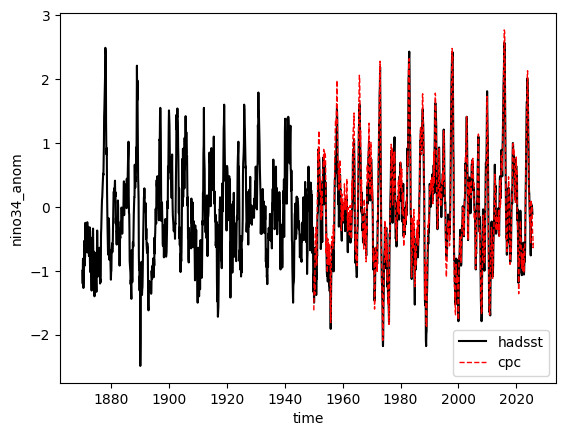

In [ ]:
nino_hadsst = load_hadsst_nino34()
nino_cpc    = load_cpc_nino34()

nino_hadsst = nino_hadsst.isel(time=slice(0,-4)) # remove last nan points

nino_hadsst['nino34_anom'].plot(c='k', label='hadsst');
nino_cpc['nino34_anom'].plot(c='r', label='cpc', ls='--', lw=1.);
plt.legend();
plt.show()

In [ ]:
DATA_DIR = Path("/content/drive/MyDrive/datasets/20CR5/")
T2M_PATH = f"{DATA_DIR}/t_americas_monthly_*.nc"
LSM_PATH = f"{DATA_DIR}/lsm_americas_2deg.nc"

# 20CRv3 files (example glob; adjust)
dst2m = xr.open_mfdataset(T2M_PATH, combine="by_coords", parallel=False, join='outer')
dst2m = dst2m - 273.15 # Kelvin to Celsius

# land mask
dslsm = xr.open_dataset(LSM_PATH)
# mask ocean
land = dslsm['lsm'] >= 0.5

# ocean becomes NaN for all times
dst2m = dst2m.where(land)

In [ ]:
# test various preprocessing
#dst2m_anom0 = monthly_anoms_baseperiod(dst2m['t'], base_start="1951-01", base_end="2000-12")
#dst2m_anom1 = detrend_quadratic(dst2m['t'])
#dst2m_anom2 = preprocess_ts_mean_plus_quad(dst2m['t'])
dst2m_anom3 = preprocess_ts_monthly_anom_plus_quad(dst2m['t'], base_start="1951-01", base_end="2000-12")

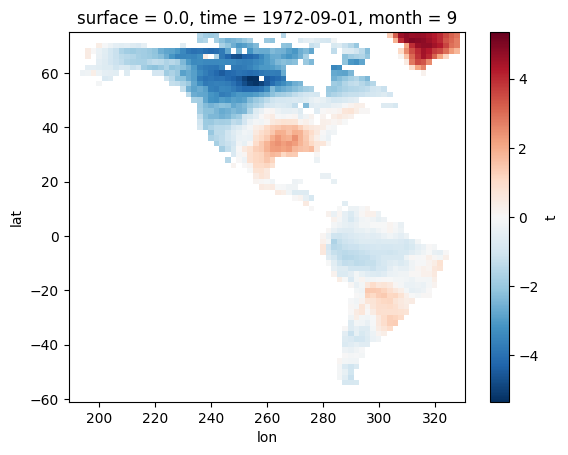

In [ ]:
#dst2m_anom0.isel(time=2000).plot(); plt.show()
#dst2m_anom1.isel(time=2000).plot(); plt.show()
#dst2m_anom2.isel(time=2000).plot(); plt.show()
dst2m_anom3.isel(time=2000).plot(); plt.show()

/tmp/ipython-input-1353130189.py:189: RuntimeWarning: Mean of empty slice
  mx = np.nanmean(xxv, axis=0)  # (P,)
/tmp/ipython-input-1353130189.py:190: RuntimeWarning: Mean of empty slice
  my = np.nanmean(yyv, axis=0)  # (P,)
/tmp/ipython-input-1353130189.py:295: RuntimeWarning: Mean of empty slice
  mx = np.nanmean(xxv, axis=0)  # (P,)
/tmp/ipython-input-1353130189.py:296: RuntimeWarning: Mean of empty slice
  my = np.nanmean(yyv, axis=0)  # (P,)


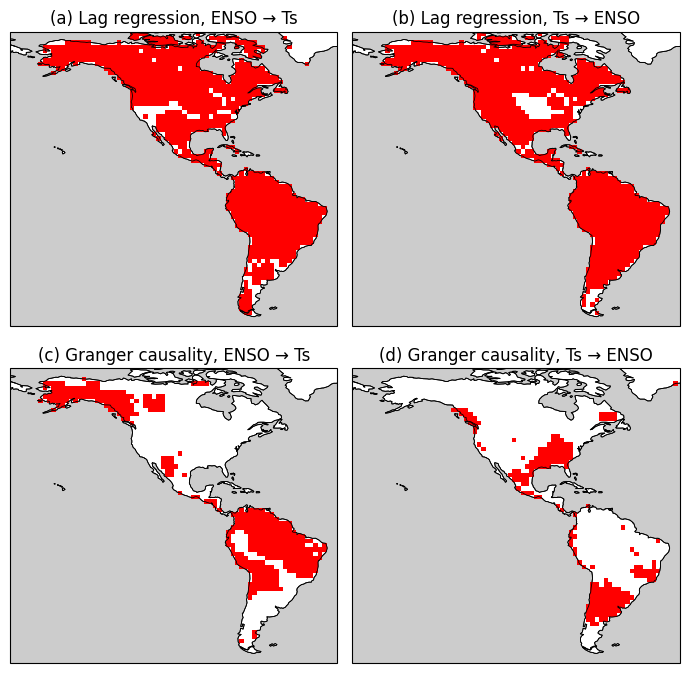

LR ENSO→Ts (land): 0.8858885017421603
LR Ts→ENSO (land): 0.8588850174216028
GC ENSO→Ts (land): 0.34146341463414637
GC Ts→ENSO (land): 0.18118466898954705


In [ ]:
enso, ts = prepare_enso_ts(nino_hadsst, dst2m_anom3)

alpha=0.05
k=7

# linear regression:
sig_lr_enso_to_ts = lagged_anysig_map_numpy(enso, ts, k=k, alpha=alpha)
sig_lr_ts_to_enso = lagged_anysig_map_ts_to_enso_numpy(ts, enso, k=k, alpha=alpha)

sig_lr_enso_to_ts.load()
sig_lr_ts_to_enso.load() # eagerly load for speed plotting

# granger tests
sig_gc_enso_to_ts = xr.DataArray(
    granger_sig_map_enso_to_ts_two_step(enso, ts, k=k, alpha=alpha),
    coords={"lat": ts["lat"], "lon": ts["lon"]}, dims=("lat","lon")
)
sig_gc_ts_to_enso = xr.DataArray(
    granger_sig_map_ts_to_enso_two_step(enso, ts, k=k, alpha=alpha),
    coords={"lat": ts["lat"], "lon": ts["lon"]}, dims=("lat","lon")
)

sig_gc_enso_to_ts.load()
sig_gc_ts_to_enso.load() # eagerly load for plotting speed

# plot 2x2 panel
fig, axes = plt.subplots(
    2, 2, figsize=(7,7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

plot_sig(axes[0,0], sig_lr_enso_to_ts, "(a) Lag regression, ENSO → Ts")
plot_sig(axes[0,1], sig_lr_ts_to_enso, "(b) Lag regression, Ts → ENSO")
plot_sig(axes[1,0], sig_gc_enso_to_ts, "(c) Granger causality, ENSO → Ts")
plot_sig(axes[1,1], sig_gc_ts_to_enso, "(d) Granger causality, Ts → ENSO")

plt.tight_layout()
plt.show()

print("LR ENSO→Ts (land):", frac_true_over_land(sig_lr_enso_to_ts, dslsm['lsm']>0.5))
print("LR Ts→ENSO (land):", frac_true_over_land(sig_lr_ts_to_enso, dslsm['lsm']>0.5))
print("GC ENSO→Ts (land):", frac_true_over_land(sig_gc_enso_to_ts, dslsm['lsm']>0.5))
print("GC Ts→ENSO (land):", frac_true_over_land(sig_gc_ts_to_enso, dslsm['lsm']>0.5))

/tmp/ipython-input-3454544525.py:189: RuntimeWarning: Mean of empty slice
  mx = np.nanmean(xxv, axis=0)  # (P,)
/tmp/ipython-input-3454544525.py:190: RuntimeWarning: Mean of empty slice
  my = np.nanmean(yyv, axis=0)  # (P,)
/tmp/ipython-input-3454544525.py:295: RuntimeWarning: Mean of empty slice
  mx = np.nanmean(xxv, axis=0)  # (P,)
/tmp/ipython-input-3454544525.py:296: RuntimeWarning: Mean of empty slice
  my = np.nanmean(yyv, axis=0)  # (P,)


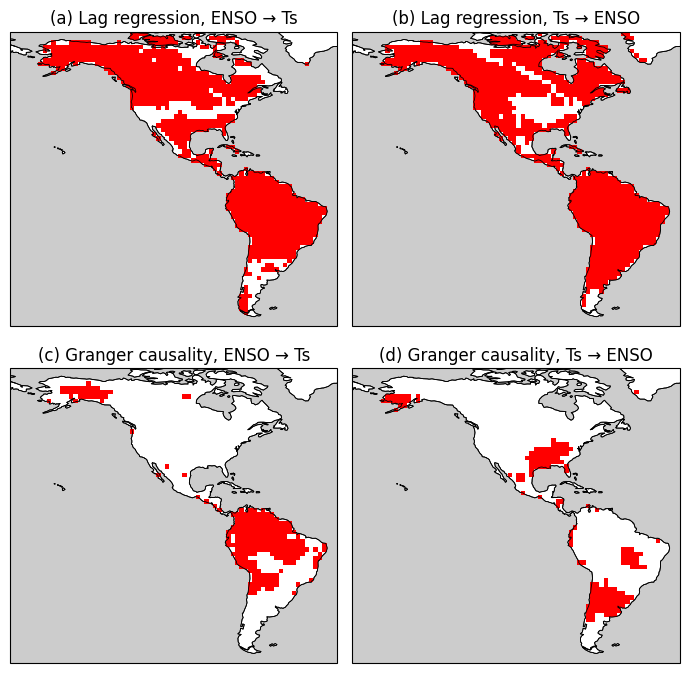

LR ENSO→Ts (land): 0.7630662020905923
LR Ts→ENSO (land): 0.8257839721254355
GC ENSO→Ts (land): 0.21951219512195122
GC Ts→ENSO (land): 0.14634146341463414


In [ ]:
enso, ts = prepare_enso_ts(nino_hadsst.sel(time=slice("1950-01", "2025-12")), dst2m_anom3.sel(time=slice("1950-01", "2025-12")))

alpha=0.05
k=7

# linear regression:
sig_lr_enso_to_ts = lagged_anysig_map_numpy(enso, ts, k=k, alpha=alpha)
sig_lr_ts_to_enso = lagged_anysig_map_ts_to_enso_numpy(ts, enso, k=k, alpha=alpha)

sig_lr_enso_to_ts.load()
sig_lr_ts_to_enso.load() # eagerly load for speed plotting

# granger tests
sig_gc_enso_to_ts = xr.DataArray(
    granger_sig_map_enso_to_ts_two_step(enso, ts, k=k, alpha=alpha),
    coords={"lat": ts["lat"], "lon": ts["lon"]}, dims=("lat","lon")
)
sig_gc_ts_to_enso = xr.DataArray(
    granger_sig_map_ts_to_enso_two_step(enso, ts, k=k, alpha=alpha),
    coords={"lat": ts["lat"], "lon": ts["lon"]}, dims=("lat","lon")
)

sig_gc_enso_to_ts.load()
sig_gc_ts_to_enso.load() # eagerly load for plotting speed

# plot 2x2 panel
fig, axes = plt.subplots(
    2, 2, figsize=(7,7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

plot_sig(axes[0,0], sig_lr_enso_to_ts, "(a) Lag regression, ENSO → Ts")
plot_sig(axes[0,1], sig_lr_ts_to_enso, "(b) Lag regression, Ts → ENSO")
plot_sig(axes[1,0], sig_gc_enso_to_ts, "(c) Granger causality, ENSO → Ts")
plot_sig(axes[1,1], sig_gc_ts_to_enso, "(d) Granger causality, Ts → ENSO")

plt.tight_layout()
plt.show()

print("LR ENSO→Ts (land):", frac_true_over_land(sig_lr_enso_to_ts, dslsm['lsm']>0.5))
print("LR Ts→ENSO (land):", frac_true_over_land(sig_lr_ts_to_enso, dslsm['lsm']>0.5))
print("GC ENSO→Ts (land):", frac_true_over_land(sig_gc_enso_to_ts, dslsm['lsm']>0.5))
print("GC Ts→ENSO (land):", frac_true_over_land(sig_gc_ts_to_enso, dslsm['lsm']>0.5))

/tmp/ipython-input-3454544525.py:189: RuntimeWarning: Mean of empty slice
  mx = np.nanmean(xxv, axis=0)  # (P,)
/tmp/ipython-input-3454544525.py:190: RuntimeWarning: Mean of empty slice
  my = np.nanmean(yyv, axis=0)  # (P,)
/tmp/ipython-input-3454544525.py:295: RuntimeWarning: Mean of empty slice
  mx = np.nanmean(xxv, axis=0)  # (P,)
/tmp/ipython-input-3454544525.py:296: RuntimeWarning: Mean of empty slice
  my = np.nanmean(yyv, axis=0)  # (P,)


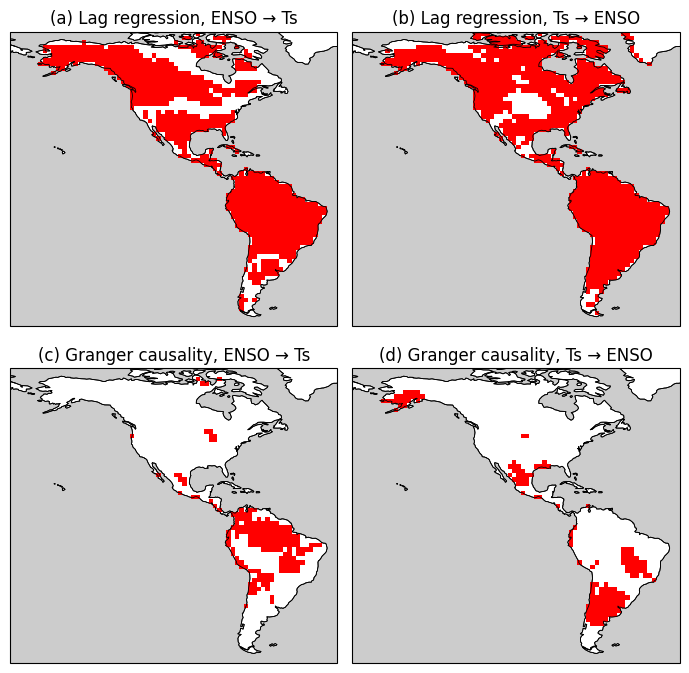

LR ENSO→Ts (land): 0.7125435540069687
LR Ts→ENSO (land): 0.8466898954703833
GC ENSO→Ts (land): 0.15940766550522648
GC Ts→ENSO (land): 0.13588850174216027


In [ ]:
enso, ts = prepare_enso_ts(nino_cpc , dst2m_anom3)

alpha=0.05
k=7

# linear regression:
sig_lr_enso_to_ts = lagged_anysig_map_numpy(enso, ts, k=k, alpha=alpha)
sig_lr_ts_to_enso = lagged_anysig_map_ts_to_enso_numpy(ts, enso, k=k, alpha=alpha)

sig_lr_enso_to_ts.load()
sig_lr_ts_to_enso.load() # eagerly load for speed plotting

# granger tests
sig_gc_enso_to_ts = xr.DataArray(
    granger_sig_map_enso_to_ts_two_step(enso, ts, k=k, alpha=alpha),
    coords={"lat": ts["lat"], "lon": ts["lon"]}, dims=("lat","lon")
)
sig_gc_ts_to_enso = xr.DataArray(
    granger_sig_map_ts_to_enso_two_step(enso, ts, k=k, alpha=alpha),
    coords={"lat": ts["lat"], "lon": ts["lon"]}, dims=("lat","lon")
)

sig_gc_enso_to_ts.load()
sig_gc_ts_to_enso.load() # eagerly load for plotting speed

# plot 2x2 panel
fig, axes = plt.subplots(
    2, 2, figsize=(7,7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

plot_sig(axes[0,0], sig_lr_enso_to_ts, "(a) Lag regression, ENSO → Ts")
plot_sig(axes[0,1], sig_lr_ts_to_enso, "(b) Lag regression, Ts → ENSO")
plot_sig(axes[1,0], sig_gc_enso_to_ts, "(c) Granger causality, ENSO → Ts")
plot_sig(axes[1,1], sig_gc_ts_to_enso, "(d) Granger causality, Ts → ENSO")

plt.tight_layout()
plt.show()

print("LR ENSO→Ts (land):", frac_true_over_land(sig_lr_enso_to_ts, dslsm['lsm']>0.5))
print("LR Ts→ENSO (land):", frac_true_over_land(sig_lr_ts_to_enso, dslsm['lsm']>0.5))
print("GC ENSO→Ts (land):", frac_true_over_land(sig_gc_enso_to_ts, dslsm['lsm']>0.5))
print("GC Ts→ENSO (land):", frac_true_over_land(sig_gc_ts_to_enso, dslsm['lsm']>0.5))

/tmp/ipython-input-1353130189.py:189: RuntimeWarning: Mean of empty slice
  mx = np.nanmean(xxv, axis=0)  # (P,)
/tmp/ipython-input-1353130189.py:190: RuntimeWarning: Mean of empty slice
  my = np.nanmean(yyv, axis=0)  # (P,)
/tmp/ipython-input-1353130189.py:295: RuntimeWarning: Mean of empty slice
  mx = np.nanmean(xxv, axis=0)  # (P,)
/tmp/ipython-input-1353130189.py:296: RuntimeWarning: Mean of empty slice
  my = np.nanmean(yyv, axis=0)  # (P,)


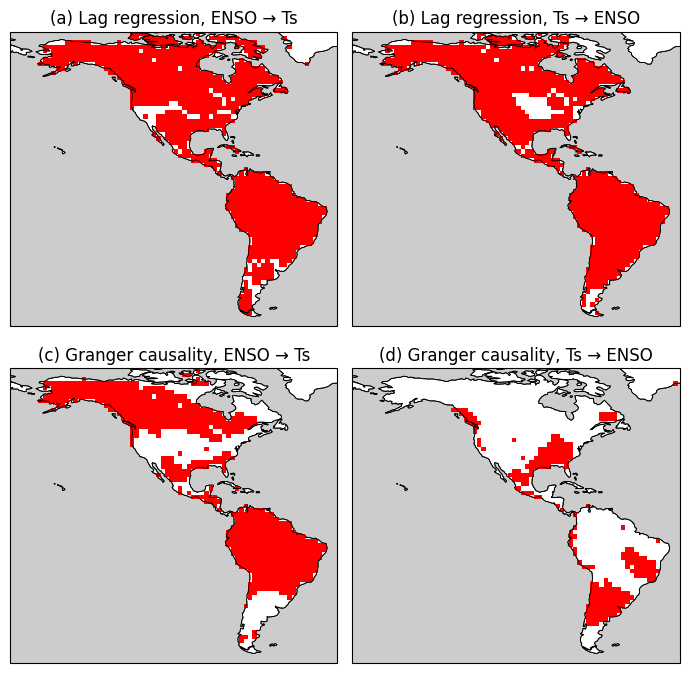

LR ENSO→Ts (land): 0.8858885017421603
LR Ts→ENSO (land): 0.8588850174216028
GC ENSO→Ts (land): 0.627177700348432
GC Ts→ENSO (land): 0.20121951219512196


In [ ]:
enso, ts = prepare_enso_ts(nino_hadsst, dst2m_anom3)

alpha=0.05
k=7

# linear regression:
sig_lr_enso_to_ts = lagged_anysig_map_numpy(enso, ts, k=k, alpha=alpha)
sig_lr_ts_to_enso = lagged_anysig_map_ts_to_enso_numpy(ts, enso, k=k, alpha=alpha)

sig_lr_enso_to_ts.load()
sig_lr_ts_to_enso.load() # eagerly load for speed plotting

# 5) granger joint-only p-values
p_gc_enso_to_ts = granger_joint_map_enso_to_ts(enso, ts, k=k)
p_gc_ts_to_enso = granger_joint_map_ts_to_enso(enso, ts, k=k)

sig_gc_enso_to_ts = p_gc_enso_to_ts < alpha
sig_gc_ts_to_enso = p_gc_ts_to_enso < alpha

sig_gc_enso_to_ts.load()
sig_gc_ts_to_enso.load() # eagerly load for plotting speed

# plot 2x2 panel
fig, axes = plt.subplots(
    2, 2, figsize=(7,7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

plot_sig(axes[0,0], sig_lr_enso_to_ts, "(a) Lag regression, ENSO → Ts")
plot_sig(axes[0,1], sig_lr_ts_to_enso, "(b) Lag regression, Ts → ENSO")
plot_sig(axes[1,0], sig_gc_enso_to_ts, "(c) Granger causality, ENSO → Ts")
plot_sig(axes[1,1], sig_gc_ts_to_enso, "(d) Granger causality, Ts → ENSO")

plt.tight_layout()
plt.show()

print("LR ENSO→Ts (land):", frac_true_over_land(sig_lr_enso_to_ts, dslsm['lsm']>0.5))
print("LR Ts→ENSO (land):", frac_true_over_land(sig_lr_ts_to_enso, dslsm['lsm']>0.5))
print("GC ENSO→Ts (land):", frac_true_over_land(sig_gc_enso_to_ts, dslsm['lsm']>0.5))
print("GC Ts→ENSO (land):", frac_true_over_land(sig_gc_ts_to_enso, dslsm['lsm']>0.5))